In [26]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

/tmp/ipykernel_5120/366717956.py:5: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  hum_data = pd.read_csv(os.path.join(path, "Relative_Humidity.csv"))


DATE
2000-01-01    87.809524
2000-01-02    86.980392
2000-01-03    76.448980
2000-01-04    76.523810
2000-01-05    78.468750
Freq: D, Name: HourlyRelativeHumidity, dtype: float64


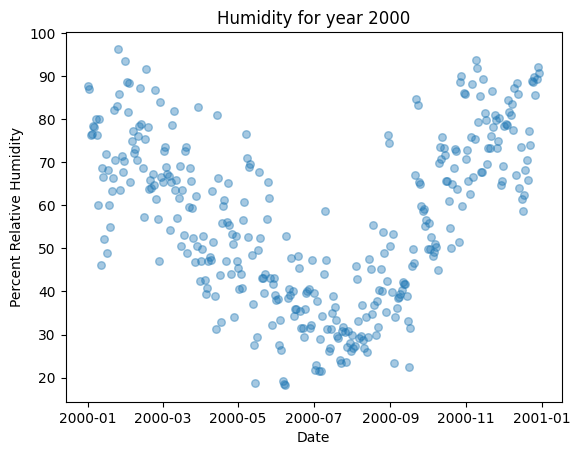

DATE
2000-01-01    87.809524
2000-01-02    86.980392
2000-01-03    76.448980
2000-01-04    76.523810
2000-01-05    78.468750
                ...    
2024-09-27    30.000000
2024-09-28    26.483871
2024-09-29    20.942857
2024-09-30    29.096774
2024-10-01    32.125000
Freq: D, Name: HourlyRelativeHumidity, Length: 9041, dtype: float64

In [ ]:
def load_hum_data(path="./data/", plot_type=None):
  

  # 1. Data loading and processing ----------------------------------
  hum_data = pd.read_csv(os.path.join(path, "Relative_Humidity.csv"))
  hum_data = hum_data[["DATE", "HourlyRelativeHumidity"]]
  hum_data["DATE"] = pd.to_datetime(hum_data["DATE"])
  hum_data = hum_data.sort_values("DATE")
  hum_data = hum_data.set_index("DATE")
  hum_data["HourlyRelativeHumidity"] = pd.to_numeric(
    hum_data["HourlyRelativeHumidity"], errors="coerce"
    )

  daily_avg = hum_data["HourlyRelativeHumidity"].resample("D").mean()

  # 2. Plotting -----------------------------------------------------
  if plot_type == "scatter":
    plt.scatter(daily_avg.index[:365], daily_avg.values[:365], s=30, alpha=0.4)
    plt.title("Humidity for year 2000")
    plt.xlabel("Date")
    plt.ylabel("Percent Relative Humidity")
    plt.show()
  
  return daily_avg


load_hum_data(plot_type="scatter")
  

/tmp/ipykernel_5120/366717956.py:5: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  hum_data = pd.read_csv(os.path.join(path, "Relative_Humidity.csv"))


DATE
2000-01-01    87.809524
2000-01-02    86.980392
2000-01-03    76.448980
2000-01-04    76.523810
2000-01-05    78.468750
Freq: D, Name: HourlyRelativeHumidity, dtype: float64
H(t) =  21.983932945514645 sin( 0.01720556258313788 t + 1.377008591148092 ) +  52.44749649176576


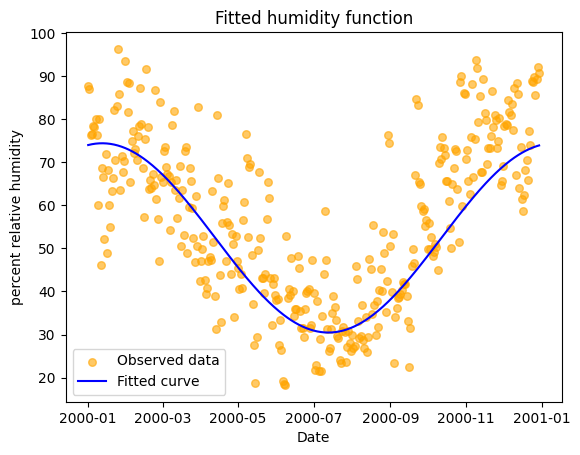

In [31]:
def fit_hum_sinusoid(show_plot=False):

  # 1. Preparing data ----------------------------------------
  hum_data = load_hum_data()

  x = (hum_data.index - hum_data.index.min()).days.to_numpy()
  y = hum_data.values

  # 2. Fitting a sinusoid curve to data ----------------------
  def sinusoid(x, A, B, phi, C):
    return A * np.sin(B * x + phi) + C

  A0 = (y.max() - y.min()) / 2
  B0 = 2 * np.pi / 365.25
  phi0 = 0
  C0 = y.mean()

  params, _ = curve_fit(sinusoid, x, y, p0=[A0, B0, phi0, C0])
  A, B, phi, C = params
  print("H(t) = ", A, "sin(", B, "t +", phi, ") + ", C)

  fitted_temp = lambda x: sinusoid(x, A, B, phi, C)

  # 3. Plotting ----------------------------------------------
  if show_plot:
    plt.scatter(hum_data.index[:365], y[:365], s=30, alpha=0.6, color="orange", label="Observed data")
    plt.plot(hum_data.index[:365], fitted_temp(x)[:365], color="blue", label="Fitted curve")
    plt.title("Fitted humidity function")
    plt.xlabel("Date")
    plt.ylabel("percent relative humidity")
    plt.legend()
    plt.savefig("./images/humidity_model.png")

  return fitted_temp

fitted_temp_sinusoid = fit_hum_sinusoid(show_plot=True)